# Whole buildings are missing from the 2024 slice of Edmonton's Historical assessment roll

**Dataset:** *Property Assessment Data (Historical)*, `qi6a-xuwt` on
`data.edmonton.ca`.

**In one sentence:** thousands of tax accounts that exist in the 2023 slice
*and* exist in the current assessment roll are absent from the 2024 slice, and
they are not scattered — entire condominium towers are gone at once.

This notebook is the evidence for a data-quality report. It is written to be
re-run by the dataset's maintainers: it downloads only from
`data.edmonton.ca`, every figure below is computed by the run you are reading,
and the exact queries are visible in the code cells.

## The one methodological point worth reading even if nothing else

The obvious way to check a historical dataset for holes is to look for records
that vanish and come back. **That check reports this defect as almost
non-existent.** It finds a handful of accounts, because the missing accounts
vanish in 2024 and never return.

Catching it requires comparing against an *independent* source — the current
assessment roll. §3 runs both and shows the difference, which is roughly two
orders of magnitude. An internal audit built the obvious way would have
reported this dataset as clean.

## Reproducing

```
pip install pandas matplotlib certifi
```

It downloads ~14 slices of account numbers (~50 MB total) and caches them, so
the first run takes a few minutes and re-runs are fast. No API token needed.

In [1]:
import base64
import io
import json
import os
import ssl
import urllib.parse
import urllib.request
from pathlib import Path

import certifi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from IPython.display import HTML, Markdown, display

SSL_CTX = ssl.create_default_context(cafile=certifi.where())
UA = "Mozilla/5.0 (compatible; edmonton-historical-gap-report/1.0)"

HISTORICAL = "qi6a-xuwt"   # Property Assessment Data (Historical)
CURRENT = "q7d6-ambg"      # Property Assessment Data (Current Calendar Year)

# Socrata truncates silently at $limit — it returns exactly that many rows and
# reports no error. Every fetch below is therefore checked against the server's
# own count(*) for the same filter; a mismatch raises rather than quietly
# analysing a partial download. That failure mode would manufacture exactly the
# defect this notebook reports, so it is not optional here.
LIMIT = 2_000_000

CACHE = Path(os.environ.get("HISTORICAL_GAP_DATA", "./historical_gap_data")).resolve()
CACHE.mkdir(parents=True, exist_ok=True)

CHECKS: list[tuple[bool, str]] = []


def check(ok: bool, claim: str) -> None:
    CHECKS.append((bool(ok), claim))
    print(f"  [{'PASS' if ok else 'FAIL'}] {claim}")


def _read(url: str) -> bytes:
    req = urllib.request.Request(url, headers={"User-Agent": UA})
    with urllib.request.urlopen(req, context=SSL_CTX, timeout=600) as r:
        return r.read()


def soda(dataset: str, params: dict, fmt: str = "csv") -> bytes:
    return _read(f"https://data.edmonton.ca/resource/{dataset}.{fmt}?"
                 + urllib.parse.urlencode(params))


def server_count(dataset: str, where: str | None = None) -> int:
    params = {"$select": "count(*) as n"}
    if where:
        params["$where"] = where
    return int(json.loads(soda(dataset, params, "json"))[0]["n"])


def fetch_frame(dataset: str, select: str, where: str | None, name: str) -> pd.DataFrame:
    """Download a slice to CSV, cached, and verify it is complete."""
    dest = CACHE / f"{name}.csv"
    if not (dest.exists() and dest.stat().st_size > 0):
        params = {"$select": select, "$limit": LIMIT}
        if where:
            params["$where"] = where
        dest.write_bytes(soda(dataset, params))
    df = pd.read_csv(dest)
    expected = server_count(dataset, where)
    if len(df) != expected:
        raise RuntimeError(
            f"{name}: downloaded {len(df):,} rows but the server reports "
            f"{expected:,} — the download is truncated or the data moved mid-run"
        )
    return df


def show(fig, alt: str) -> None:
    """Display a figure carrying real alt text (plt.show() emits none)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, facecolor=fig.get_facecolor())
    plt.close(fig)
    display(HTML(f'<img alt="{alt}" '
                 f'src="data:image/png;base64,{base64.b64encode(buf.getvalue()).decode()}">'))


print(f"cache: {CACHE}")

cache: /tmp/historical_gap_data


---
## 1. The symptom is visible in a single aggregate query

Before downloading anything substantial: how many accounts does each year's
slice contain? Edmonton grows steadily, so account counts should rise steadily.

In [2]:
per_year = pd.read_csv(io.BytesIO(soda(HISTORICAL, {
    "$select": "assessment_year,count(*) as accounts",
    "$group": "assessment_year",
    "$order": "assessment_year",
    "$limit": 100,
})))
per_year["year"] = per_year["assessment_year"].astype(str).str[:4].astype(int)
per_year = per_year[["year", "accounts"]].set_index("year")
per_year["growth"] = per_year["accounts"].diff()

print(per_year.to_string(na_rep="—", formatters={
    "accounts": lambda v: f"{v:,.0f}",
    "growth": lambda v: f"{v:+,.0f}",
}))

growth = per_year["growth"].dropna()
ODD_YEAR = int(growth.idxmin())
others = growth.drop(ODD_YEAR)

display(Markdown(
    f"**{ODD_YEAR} added {growth[ODD_YEAR]:+,.0f} accounts.** Every other year in "
    f"the dataset added between {others.min():+,.0f} and {others.max():+,.0f} — so "
    f"{ODD_YEAR}'s growth is about **{others.median() / growth[ODD_YEAR]:.0f}×** "
    f"below the median year. Nothing about Edmonton in {ODD_YEAR} explains that; "
    f"the following year returns to {growth[per_year.index.max()]:+,.0f}."
))

check(growth[ODD_YEAR] < others.min(),
      f"{ODD_YEAR} is the slowest-growing slice in the dataset, by inspection of the data")

     accounts  growth
year                 
2012  337,298       —
2013  346,108  +8,810
2014  355,767  +9,659
2015  367,386 +11,619
2016  381,025 +13,639
2017  389,274  +8,249
2018  396,159  +6,885
2019  402,419  +6,260
2020  409,384  +6,965
2021  413,809  +4,425
2022  418,982  +5,173
2023  425,728  +6,746
2024  426,913  +1,185
2025  431,706  +4,793


**2024 added +1,185 accounts.** Every other year in the dataset added between +4,425 and +13,639 — so 2024's growth is about **6×** below the median year. Nothing about Edmonton in 2024 explains that; the following year returns to +4,793.

  [PASS] 2024 is the slowest-growing slice in the dataset, by inspection of the data



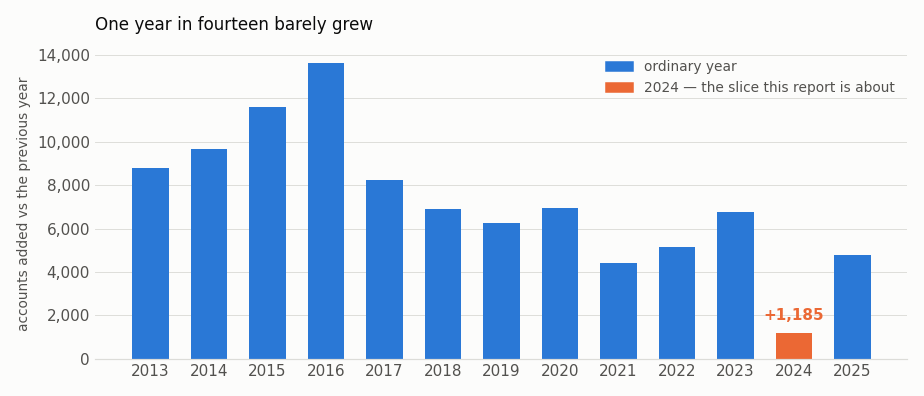

In [3]:
# --- chart 1 ---------------------------------------------------------------
# Form: magnitude over an ordered sequence -> bar (not a line: these are
# year-over-year deltas, discrete quantities per year, not a continuous level).
# Two categories (ordinary year / the flagged year), so a legend is present and
# the flagged bar is also direct-labelled — identity never rests on colour alone.
SURFACE, INK, INK_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dcdcd8"
BLUE, ORANGE = "#2a78d6", "#eb6834"   # validated categorical slots 1 and 2

fig, ax = plt.subplots(figsize=(8.4, 3.6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
colors = [ORANGE if y == ODD_YEAR else BLUE for y in growth.index]
ax.bar(growth.index.astype(str), growth.values, color=colors, width=0.62)
ax.text(list(growth.index).index(ODD_YEAR), growth[ODD_YEAR] + others.max() * 0.045,
        f"{growth[ODD_YEAR]:+,.0f}", ha="center", color=ORANGE, fontsize=10, weight="bold")

handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE),
           plt.Rectangle((0, 0), 1, 1, color=ORANGE)]
ax.legend(handles, ["ordinary year", f"{ODD_YEAR} — the slice this report is about"],
          loc="upper right", frameon=False, fontsize=9, labelcolor=INK_MUTED)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_ylabel("accounts added vs the previous year", color=INK_MUTED, fontsize=9)
ax.set_title("One year in fourteen barely grew", color=INK, fontsize=11, loc="left", pad=12)
ax.grid(axis="y", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=INK_MUTED, length=0)
plt.tight_layout()
show(fig, f"Bar chart of accounts added each year in the Historical assessment dataset. "
          f"Every year from 2013 to 2025 adds between {others.min():,.0f} and "
          f"{others.max():,.0f} accounts except {ODD_YEAR}, which adds only "
          f"{growth[ODD_YEAR]:,.0f} — a fraction of every other year, and the slice this "
          f"report concerns.")

A slow year is a hint, not a defect. The rest of this establishes that
specific, identifiable accounts are missing.

---
## 2. Downloading the account sets

One column — `account_number` — for every year, plus the current roll as an
independent control. Each download is verified against the server's own
`count(*)`, because Socrata truncates silently at `$limit`.

In [4]:
years = list(per_year.index)
hist_accounts: dict[int, set] = {}
for y in years:
    df = fetch_frame(HISTORICAL, "account_number", f"assessment_year='{y}'", f"hist_{y}")
    hist_accounts[y] = set(df["account_number"])
    dupes = len(df) - len(hist_accounts[y])
    print(f"  {y}: {len(df):>9,} rows  {len(hist_accounts[y]):>9,} distinct"
          f"{'  ⚠ ' + str(dupes) + ' duplicate account numbers' if dupes else ''}")

current_df = fetch_frame(CURRENT, "account_number", None, "current_roll")
current = set(current_df["account_number"])
print(f"\n  current roll: {len(current_df):,} rows, {len(current):,} distinct")

check(all(len(hist_accounts[y]) == server_count(HISTORICAL, f"assessment_year='{y}'")
          for y in years),
      "every year's download matches the server's own row count (nothing truncated)")

  2012:   337,298 rows    337,298 distinct


  2013:   346,108 rows    346,108 distinct


  2014:   355,767 rows    355,767 distinct


  2015:   367,386 rows    367,386 distinct


  2016:   381,025 rows    381,025 distinct


...

  2023:   425,728 rows    425,728 distinct


  2024:   426,913 rows    426,913 distinct


  2025:   431,706 rows    431,706 distinct



  current roll: 439,634 rows, 439,634 distinct


  [PASS] every year's download matches the server's own row count (nothing truncated)


---
## 3. Two ways to look for missing accounts, and why one of them lies

**Detector A — self-audit.** An account present in year *N−1* and again in
*N+1*, but absent from *N*. Buildings do not blink out of existence for a year.
This needs no external data, which makes it the natural thing to build.

**Detector B — current-roll control.** An account present in year *N−1* and
present in the **current** assessment roll, but absent from *N*. A property
that existed before and still exists today cannot legitimately be missing in
between.

Neither is sufficient alone. A is blind to any account that disappears and
never comes back. B is blind to properties genuinely demolished since. The
honest answer is their union — but the gap *between* them is the finding.

In [5]:
rows = []
for i, y in enumerate(years):
    prev = years[i - 1] if i > 0 else None
    nxt = years[i + 1] if i + 1 < len(years) else None
    if prev is None:
        continue
    a = ((hist_accounts[prev] & hist_accounts[nxt]) - hist_accounts[y]) if nxt else None
    b = (hist_accounts[prev] & current) - hist_accounts[y]
    union = (a | b) if a is not None else b
    rows.append({"year": y,
                 "detector_A": len(a) if a is not None else None,
                 "detector_B": len(b),
                 "union": len(union),
                 "rate": 100 * len(union) / len(hist_accounts[y])})

defects = pd.DataFrame(rows).set_index("year")
print(defects.to_string(formatters={
    "detector_A": lambda v: "n/a" if pd.isna(v) else f"{v:,.0f}",
    "detector_B": lambda v: f"{v:,.0f}",
    "union": lambda v: f"{v:,.0f}",
    "rate": lambda v: f"{v:.2f}%",
}))

     detector_A detector_B union  rate
year                                  
2013          0          2     2 0.00%
2014          0          0     0 0.00%
2015          0          0     0 0.00%
2016          0          1     1 0.00%
2017          0          1     1 0.00%
2018          0         14    14 0.00%
2019          1          8     8 0.00%
2020          1          1     1 0.00%
2021          0          5     5 0.00%
2022          1          1     2 0.00%
2023          0          0     0 0.00%
2024          5      2,321 2,322 0.54%
2025        NaN        131   131 0.03%


In [6]:
worst = int(defects["union"].idxmax())
wa, wb = defects.loc[worst, "detector_A"], defects.loc[worst, "detector_B"]
clean = defects.drop(worst)

display(Markdown(
    f"### The two detectors disagree by {wb / max(wa, 1):.0f}×\n\n"
    f"For **{worst}**, the self-audit finds **{wa:,.0f}** accounts. The "
    f"current-roll control finds **{wb:,.0f}** — because the missing accounts "
    f"vanish in {worst} and *stay* vanished, which is precisely the shape the "
    f"self-audit cannot see.\n\n"
    f"Every other testable year sits at or below "
    f"**{clean['union'].max():,.0f}** accounts "
    f"(**{clean['rate'].max():.2f}%**). This is one event, not gradual decay — "
    f"{len(clean[clean['union'] <= 20]):,} of {len(defects):,} testable years are "
    f"effectively clean."
))

check(defects.loc[worst, "union"] > 10 * clean["union"].max(),
      f"{worst} is an outlier by an order of magnitude, not the top of a gradient")
check(wb > wa,
      "the current-roll control finds strictly more than the self-audit — "
      "a self-audit alone understates this defect")

### The two detectors disagree by 464×

For **2024**, the self-audit finds **5** accounts. The current-roll control finds **2,321** — because the missing accounts vanish in 2024 and *stay* vanished, which is precisely the shape the self-audit cannot see.

Every other testable year sits at or below **131** accounts (**0.03%**). This is one event, not gradual decay — 11 of 13 testable years are effectively clean.

  [PASS] 2024 is an outlier by an order of magnitude, not the top of a gradient
  [PASS] the current-roll control finds strictly more than the self-audit — a self-audit alone understates this defect


---
## 4. What is actually missing

The cumulative view: accounts present in the last sound year *and* present in
the current roll, but absent from the most recent slice. These are the
accounts a user of this dataset silently loses today.

In [7]:
last_sound = worst - 1
latest = max(years)
cumulative = (hist_accounts[last_sound] & current) - hist_accounts[latest]

detail = fetch_frame(
    HISTORICAL,
    "account_number,assessed_value,neighbourhood_name,house_number,street_name",
    f"assessment_year='{last_sound}'", f"detail_{last_sound}",
).drop_duplicates("account_number").set_index("account_number")
missing = detail.loc[sorted(cumulative & set(detail.index))].copy()

print(f"accounts in {last_sound} and in the current roll, but absent from {latest}: "
      f"{len(cumulative):,}")
print(f"their combined {last_sound} assessed value: ${missing['assessed_value'].sum():,.0f}")
print(f"neighbourhoods affected: {missing['neighbourhood_name'].nunique():,}")

check(len(missing) > 0, "the cumulative missing set is non-empty")

accounts in 2023 and in the current roll, but absent from 2025: 2,448
their combined 2023 assessed value: $3,008,124,000
neighbourhoods affected: 188
  [PASS] the cumulative missing set is non-empty


> ⚠️ **Do not add the per-year counts together.** An account already absent in
> one year cannot be flagged again in the next, and a handful of accounts
> return. The per-year figures in §3 and the cumulative figure here answer
> different questions; summing them produces a number that is wrong by exactly
> the returning accounts. The cell below shows the discrepancy rather than
> hiding it.

In [8]:
per_year_sum = int(defects.loc[worst, "union"] + defects.loc[latest, "union"])
display(Markdown(
    f"Adding the two affected years gives **{per_year_sum:,}**. The cumulative "
    f"set is **{len(cumulative):,}**. The difference of **{per_year_sum - len(cumulative):,}** "
    f"is accounts that dropped out and later returned — which is why this report "
    f"quotes one figure at a time and says which question it answers."
))

Adding the two affected years gives **2,453**. The cumulative set is **2,448**. The difference of **5** is accounts that dropped out and later returned — which is why this report quotes one figure at a time and says which question it answers.

In [9]:
by_hood = (missing.groupby("neighbourhood_name")["assessed_value"]
           .agg(accounts="size", value="sum")
           .sort_values("value", ascending=False))
total_val = missing["assessed_value"].sum()
print(f"{'neighbourhood':<30}{'accounts':>10}{'value':>18}{'share':>9}")
for name, r in by_hood.head(10).iterrows():
    print(f"{name:<30}{int(r['accounts']):>10,}"
          f"{'$' + format(r['value'], ',.0f'):>18}"
          f"{100 * r['value'] / total_val:>8.1f}%")

neighbourhood                   accounts             value    share
DOWNTOWN                           1,292    $1,457,379,500    48.4%
UNIVERSITY OF ALBERTA                  2      $195,024,000     6.5%
GLENORA                              269       $63,077,500     2.1%
KESWICK                                2       $58,361,000     1.9%
MAGRATH HEIGHTS                      430       $55,687,500     1.9%
CHAPPELLE AREA                         2       $54,673,000     1.8%
WALKER                                 2       $53,469,000     1.8%
MCCONACHIE                             2       $47,583,000     1.6%
THE ORCHARDS AT ELLERSLIE              2       $45,715,000     1.5%
CLOVER BAR AREA                        7       $31,865,000     1.1%


---
## 5. The shape of it: whole buildings, not scattered records

This is the part that should make the cause findable. The missing accounts are
not spread thinly across the city — they cluster at a small number of street
addresses, and at many of those addresses **every** account is gone.

In [10]:
missing["address"] = (missing["house_number"].astype("Int64").astype(str)
                      + " " + missing["street_name"].fillna(""))
all_at_address = (detail.assign(address=detail["house_number"].astype("Int64").astype(str)
                                + " " + detail["street_name"].fillna(""))
                  .groupby("address").size())

buildings = (missing.groupby("address")
             .agg(missing_accounts=("assessed_value", "size"),
                  value=("assessed_value", "sum"),
                  neighbourhood=("neighbourhood_name", "first"))
             .assign(total=lambda d: all_at_address.reindex(d.index))
             .assign(pct=lambda d: 100 * d["missing_accounts"] / d["total"])
             .sort_values("missing_accounts", ascending=False))

multi = buildings[buildings["missing_accounts"] > 1]
whole = buildings[(buildings["missing_accounts"] > 1) & (buildings["pct"] >= 99)]

print(f"missing accounts:                    {len(missing):,}")
print(f"distinct street addresses:           {len(buildings):,}")
print(f"accounts at a multi-unit address:    {int(multi['missing_accounts'].sum()):,} "
      f"({100 * multi['missing_accounts'].sum() / len(missing):.1f}%)")
print(f"addresses losing EVERY account:      {len(whole):,} "
      f"({int(whole['missing_accounts'].sum()):,} accounts)")

print(f"\n{'units':>7}  {'value':>16}  {'of addr':>8}  address")
for addr, r in buildings.head(10).iterrows():
    print(f"{int(r['missing_accounts']):>7,}  {'$' + format(r['value'], ',.0f'):>16}  "
          f"{r['pct']:>7.0f}%  {addr}  ({r['neighbourhood']})")

check(multi["missing_accounts"].sum() > 0,
      "missing accounts cluster at shared addresses rather than being scattered")

missing accounts:                    2,448
distinct street addresses:           272
accounts at a multi-unit address:    1,034 (42.2%)
addresses losing EVERY account:      29 (969 accounts)

  units             value   of addr  address
    309      $144,451,500      100%  10310 102 STREET NW  (DOWNTOWN)
    261      $205,950,500      100%  10360 102 STREET NW  (DOWNTOWN)
    162       $52,377,500      100%  7463 MAY COMMON NW  (MAGRATH HEIGHTS)
    123       $14,864,000      100%  10155 116 STREET NW  (OLIVER)
     60       $51,370,000      100%  14105 WEST BLOCK DRIVE NW  (GLENORA)
     19       $14,302,800       68%  10035 156 STREET NW  (WEST JASPER PLACE)
      9        $2,209,500       75%  9100 WALTERDALE HILL NW  (RIVER VALLEY WALTERDALE)
      6        $6,846,500       86%  14101 WEST BLOCK DRIVE NW  (GLENORA)
      5        $6,368,000       83%  2704 17 STREET NW  (SILVER BERRY)
      4        $1,642,000      100%  10310 102 SSTREET NW  (DOWNTOWN)
  [PASS] missing accounts clu

### An aside, and a caveat on the count above

Addresses are grouped on the published `house_number` + `street_name` strings
exactly as they appear. Those strings are not clean, so one building can be
split across several spellings — which means the distinct-address count above
is an **upper bound** on the number of distinct buildings, and the per-address
unit counts are lower bounds.

This is incidental to the missing-records problem, but it is in the same
dataset and is easy to fix, so it is reported here too.

In [11]:
variants = buildings.reset_index()
variants["house"] = variants["address"].str.split().str[0]
clashes = variants[variants.duplicated(subset=["house", "neighbourhood"], keep=False)]

if len(clashes):
    print("same house number and neighbourhood, different street-name spelling:\n")
    for _, r in clashes.sort_values(["neighbourhood", "house", "missing_accounts"],
                                    ascending=[True, True, False]).iterrows():
        print(f"  {int(r['missing_accounts']):>4,} units  {r['address']:<24} ({r['neighbourhood']})")
    merged = clashes.groupby(["house", "neighbourhood"])["missing_accounts"].sum()
    print(f"\nMerging the spellings, the largest affected building loses "
          f"{int(merged.max()):,} accounts, not {int(buildings['missing_accounts'].max()):,}.")
else:
    print("no same-house-number spelling variants found in the affected set")

same house number and neighbourhood, different street-name spelling:

   309 units  10310 102 STREET NW      (DOWNTOWN)
     4 units  10310 102 SSTREET NW     (DOWNTOWN)
     2 units  10310 102 STSREET NW     (DOWNTOWN)

Merging the spellings, the largest affected building loses 315 accounts, not 309.



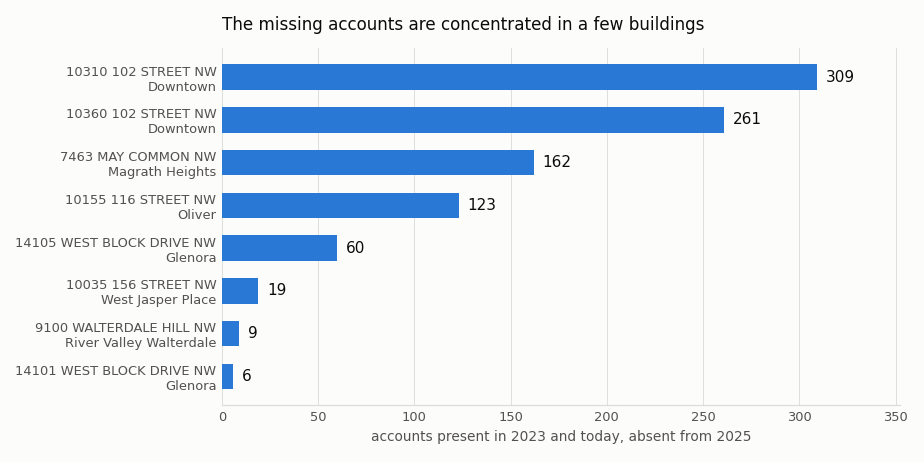

In [12]:
# --- chart 2 ---------------------------------------------------------------
# Form: magnitude across a few named items -> bar. One series, so no legend;
# every bar is direct-labelled because the reader wants the count, not a
# position on a scale.
top = buildings.head(8).iloc[::-1]
labels = [f"{a}\n{r['neighbourhood'].title()}" for a, r in top.iterrows()]

fig, ax = plt.subplots(figsize=(8.4, 4.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.barh(labels, top["missing_accounts"], color=BLUE, height=0.6)
for rect, v in zip(bars, top["missing_accounts"]):
    ax.text(rect.get_width() + top["missing_accounts"].max() * 0.015,
            rect.get_y() + rect.get_height() / 2, f"{int(v):,}",
            va="center", ha="left", color=INK, fontsize=10)

ax.set_xlim(0, top["missing_accounts"].max() * 1.14)
ax.set_xlabel(f"accounts present in {last_sound} and today, absent from {latest}",
              color=INK_MUTED, fontsize=9)
ax.set_title("The missing accounts are concentrated in a few buildings",
             color=INK, fontsize=11, loc="left", pad=12)
ax.grid(axis="x", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=INK_MUTED, length=0, labelsize=8.5)
plt.tight_layout()
show(fig, f"Horizontal bar chart of the eight street addresses with the most accounts "
          f"missing from the {latest} slice. The largest single address accounts for "
          f"{int(buildings['missing_accounts'].max()):,} units, and the top addresses are "
          f"multi-storey residential buildings, showing the loss is concentrated in whole "
          f"buildings rather than spread across the city.")

### A sample to check by hand

Account numbers from the largest affected address, so the behaviour can be
confirmed directly against the portal without re-running any of this.

In [13]:
biggest = buildings.index[0]
sample = missing[missing["address"] == biggest].head(12)
print(f"address: {biggest}  ({sample['neighbourhood_name'].iloc[0]})\n")
print(f"{'account':>12}  {last_sound} assessed value")
for acct, r in sample.iterrows():
    print(f"{acct:>12}  ${r['assessed_value']:>14,.0f}")

print(f"\nEach of these appears in the {last_sound} slice and in the current roll,")
print(f"and none appears in the {worst} or {latest} slices. To confirm one:")
print(f"  https://data.edmonton.ca/resource/{HISTORICAL}.json"
      f"?account_number={sample.index[0]}")

address: 10310 102 STREET NW  (DOWNTOWN)

     account  2023 assessed value
    10971402  $       449,500
    10971403  $       311,500
    10971404  $       448,500
    10971405  $       351,500
    10971406  $       354,500
    10971407  $       715,000
    10971408  $       576,000
    10971409  $       399,500
    10971410  $       374,000
    10971411  $       374,500
    10971412  $       387,000
    10971413  $       384,000

Each of these appears in the 2023 slice and in the current roll,
and none appears in the 2024 or 2025 slices. To confirm one:
  https://data.edmonton.ca/resource/qi6a-xuwt.json?account_number=10971402


---
## 6. Why this matters to someone using the dataset

- **A time series built from this dataset is wrong and gives no warning.** The
  accounts do not appear as nulls or zeroes; the rows are simply absent, so
  every per-year total, per-neighbourhood total and growth rate computed from
  the affected slices is understated with nothing to indicate it.
- **The affected year's values are unrecoverable.** The current roll can
  substitute for the most recent slice, but there is no current-roll
  equivalent for a past year — those assessments exist nowhere else public.
  Any series over this period has to omit the year outright rather than
  interpolate across it.
- **The distortion is concentrated, not diffuse.** Because the loss is
  building-shaped, it falls hardest on the densest neighbourhoods, which is
  exactly where a downtown-vs-suburb comparison would be drawn.

## 7. What would resolve it

Republishing the affected slices with the missing accounts restored. Failing
that, a documented note on the dataset stating which years are incomplete
would at least let users omit them deliberately rather than discovering this
on their own.

## 8. What this notebook does not claim

- **It does not diagnose the cause.** It reports a symptom and its shape. The
  building-level clustering is offered because it is likely to be useful in
  locating the cause, not as a theory about what happened.
- **It does not claim the affected accounts are untaxed or unassessed.** They
  are present in the current roll and were present before; only these
  historical slices are missing them.
- **It does not claim every affected account is found.** Both detectors are
  blind to a property that was demolished after the affected year and is
  therefore in neither the later slices nor the current roll. The true figure
  can only be higher than what is reported here.

In [14]:
passed = sum(1 for ok, _ in CHECKS if ok)
print(f"invariants checked: {passed}/{len(CHECKS)} passed\n")
for ok, claim in CHECKS:
    print(f"  [{'PASS' if ok else 'FAIL'}] {claim}")
if passed != len(CHECKS):
    raise AssertionError(f"{len(CHECKS) - passed} invariant(s) failed — see above")
print("\nAll structural invariants held.")

invariants checked: 6/6 passed

  [PASS] 2024 is the slowest-growing slice in the dataset, by inspection of the data
  [PASS] every year's download matches the server's own row count (nothing truncated)
  [PASS] 2024 is an outlier by an order of magnitude, not the top of a gradient
  [PASS] the current-roll control finds strictly more than the self-audit — a self-audit alone understates this defect
  [PASS] the cumulative missing set is non-empty
  [PASS] missing accounts cluster at shared addresses rather than being scattered

All structural invariants held.
